In [20]:
!pip install kaggle

Kaggle API key installed successfully.
Dataset already downloaded.
Dataset already extracted.
Dataset ready!
Dataset split into train/val/test successfully!
Train folder exists: True
Val folder exists: True
Test folder exists: True
Previewing training samples...


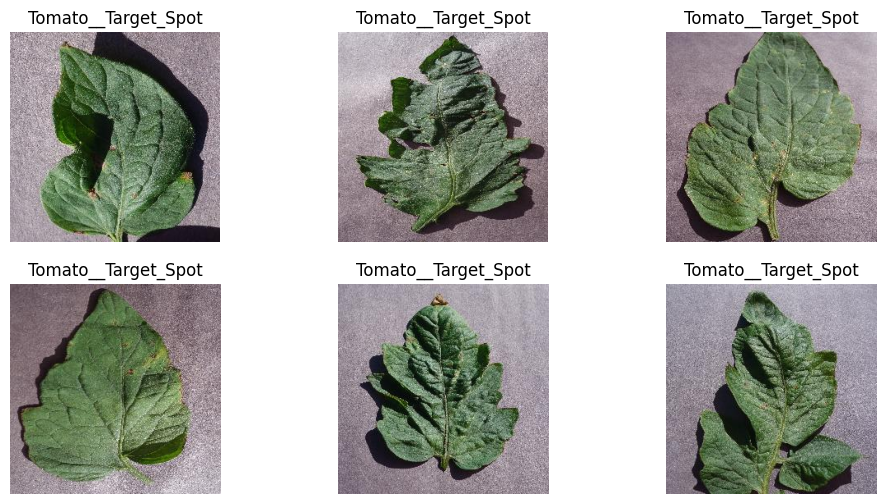

Found 16505 images belonging to 15 classes.
Found 2063 images belonging to 15 classes.
Found 2070 images belonging to 15 classes.
Classes: {'Pepper__bell___Bacterial_spot': 0, 'Pepper__bell___healthy': 1, 'Potato___Early_blight': 2, 'Potato___Late_blight': 3, 'Potato___healthy': 4, 'Tomato_Bacterial_spot': 5, 'Tomato_Early_blight': 6, 'Tomato_Late_blight': 7, 'Tomato_Leaf_Mold': 8, 'Tomato_Septoria_leaf_spot': 9, 'Tomato_Spider_mites_Two_spotted_spider_mite': 10, 'Tomato__Target_Spot': 11, 'Tomato__Tomato_YellowLeaf__Curl_Virus': 12, 'Tomato__Tomato_mosaic_virus': 13, 'Tomato_healthy': 14}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │         1,935 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,306,575 (12.61 MB)

 Trainable params: 3,306,575 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
 92/516 ━━━━━━━━━━━━━━━━━━━━ 7:30 1s/step - accuracy: 0.2120 - loss: 2.4172

In [ ]:
# ============================================================
#   CROP DISEASE DETECTION USING SIMPLE CNN (PLANTVILLAGE)
#   Fully Automated Notebook (Colab + Secrets)
#   Author: Yahya
# ============================================================

import os
import zipfile
import shutil
import random
import json

import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

from google.colab import userdata
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img
from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix, classification_report

# ============================================================
# 1. LOAD KAGGLE API KEY FROM COLAB SECRETS
# ============================================================

kaggle_key = userdata.get('KAGGLE_API_TOKEN')  # value in Colab

if kaggle_key is None:
    raise Exception("Kaggle key not found in Colab Secrets. Add it under Settings → Secrets → KAGGLE_")

kaggle_username = "write_your_own_kaggle_username"  # replace with Kaggle username

os.makedirs("/root/.kaggle", exist_ok=True)

with open("/root/.kaggle/kaggle.json", "w") as f:
    json.dump({"username": kaggle_username, "key": kaggle_key}, f)

os.chmod("/root/.kaggle/kaggle.json", 600)

print("Kaggle API key installed successfully.")

# ============================================================
# 2. DOWNLOAD PLANTVILLAGE DATASET FROM KAGGLE
# ============================================================

DATASET_ZIP = "plantdisease.zip"

if not os.path.exists(DATASET_ZIP):
    print("Downloading PlantVillage dataset...")
    !kaggle datasets download -d emmarex/plantdisease -o
else:
    print("Dataset already downloaded.")

# ============================================================
# 3. EXTRACT DATASET
# ============================================================

DATA_DIR = "data"

if not os.path.exists(DATA_DIR):
    print("Extracting dataset...")
    with zipfile.ZipFile(DATASET_ZIP, 'r') as zip_ref:
        for file in tqdm(zip_ref.namelist()):
            zip_ref.extract(file, DATA_DIR)
else:
    print("Dataset already extracted.")

print("Dataset ready!")

# ============================================================
# 4. AUTO-SPLIT INTO TRAIN / VAL / TEST
# ============================================================

SOURCE_DIR = os.path.join(DATA_DIR, "PlantVillage")
TARGET_DIR = DATA_DIR

train_path = os.path.join(TARGET_DIR, "train")
val_path   = os.path.join(TARGET_DIR, "val")
test_path  = os.path.join(TARGET_DIR, "test")

for p in [train_path, val_path, test_path]:
    os.makedirs(p, exist_ok=True)

for cls in os.listdir(SOURCE_DIR):
    cls_path = os.path.join(SOURCE_DIR, cls)
    if not os.path.isdir(cls_path):
        continue

    images = os.listdir(cls_path)
    random.shuffle(images)

    n = len(images)
    train_split = int(0.8 * n)
    val_split   = int(0.9 * n)

    train_imgs = images[:train_split]
    val_imgs   = images[train_split:val_split]
    test_imgs  = images[val_split:]

    os.makedirs(os.path.join(train_path, cls), exist_ok=True)
    os.makedirs(os.path.join(val_path, cls), exist_ok=True)
    os.makedirs(os.path.join(test_path, cls), exist_ok=True)

    for img in train_imgs:
        shutil.copy(os.path.join(cls_path, img), os.path.join(train_path, cls))

    for img in val_imgs:
        shutil.copy(os.path.join(cls_path, img), os.path.join(val_path, cls))

    for img in test_imgs:
        shutil.copy(os.path.join(cls_path, img), os.path.join(test_path, cls))

print("Dataset split into train/val/test successfully!")

print("Train folder exists:", os.path.exists(train_path))
print("Val folder exists:", os.path.exists(val_path))
print("Test folder exists:", os.path.exists(test_path))

# ============================================================
# 5. PREVIEW SAMPLE IMAGES
# ============================================================

def preview_samples(folder, n=6):
    classes = os.listdir(folder)
    sample_class = classes[0]
    sample_dir = os.path.join(folder, sample_class)
    sample_images = os.listdir(sample_dir)[:n]

    plt.figure(figsize=(12,6))
    for i, img_name in enumerate(sample_images):
        img_path = os.path.join(sample_dir, img_name)
        img = load_img(img_path)
        plt.subplot(2,3,i+1)
        plt.imshow(img)
        plt.title(sample_class)
        plt.axis("off")
    plt.show()

print("Previewing training samples...")
preview_samples(train_path)

# ============================================================
# 6. LOAD DATA WITH KERAS GENERATORS
# ============================================================

IMG_SIZE = (128, 128)
BATCH_SIZE = 32

train_gen = ImageDataGenerator(rescale=1/255.0)
val_gen   = ImageDataGenerator(rescale=1/255.0)
test_gen  = ImageDataGenerator(rescale=1/255.0)

train_data = train_gen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_data = val_gen.flow_from_directory(
    val_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_data = test_gen.flow_from_directory(
    test_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print("Classes:", train_data.class_indices)

# ============================================================
# 7. BUILD SIMPLE CNN MODEL
# ============================================================

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(train_data.num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# ============================================================
# 8. TRAIN MODEL
# ============================================================

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

# ============================================================
# 9. PLOT TRAINING CURVES
# ============================================================

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Loss")
plt.legend()

plt.show()

# ============================================================
# 10. EVALUATE ON TEST SET
# ============================================================

test_loss, test_acc = model.evaluate(test_data)
print("Test Accuracy:", test_acc)

# ============================================================
# 11. CONFUSION MATRIX + CLASSIFICATION REPORT
# ============================================================

y_true = test_data.classes
y_pred = np.argmax(model.predict(test_data), axis=1)

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred))

cm = confusion_matrix(y_true, y_pred)
print("\nConfusion Matrix:\n")
print(cm)

# ============================================================
# 12. VISUALIZE SAMPLE PREDICTIONS
# ============================================================

def show_predictions(n=6):
    x, y = next(test_data)
    preds = model.predict(x)
    preds = np.argmax(preds, axis=1)
    labels = list(test_data.class_indices.keys())

    plt.figure(figsize=(12,8))
    for i in range(n):
        plt.subplot(2,3,i+1)
        plt.imshow(x[i])
        plt.title(f"Pred: {labels[preds[i]]}")
        plt.axis("off")

show_predictions()

# ============================================================
# 13. SAVE MODEL (OPTIONAL)
# ============================================================

model.save("crop_disease_cnn.h5")
print("Model saved as crop_disease_cnn.h5")
